# **Diagnosing Time Series Data**

In [1]:
import os
os.chdir("D:\\Tutoring\\Time_Series_R\\Time_Series_Analysis_python")

## Load Libraries

In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from scipy.fft import fft
from scipy.signal import detrend, find_peaks

from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.filters.hp_filter import hpfilter

import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'
plt.rcParams["font.serif"] = 'Times New Roman'
import seaborn as sns

from IPython.display import display, HTML

## **Identify the dominant period/frequency**
<hr style="margin-top: -20px;">

The decomposition techniques expects the dominant period as a parameter. In our previous class, we used a `period` value based on our initial assumption based on the data.

<p align="center">🤔<i>But how do we determine the dominant period?</i></p>
We can use one of the following techniques:

- Plot the data and try to figure out after how many steps the cycle repeats.
- Do an Autocorrelation Plot (more on this later).
- Use the Fast Fourier Transform on a signal without trend.

We are going to create a function to compute the **dominant period** in the data. The algorithm of the function is as follows:
1. We will use the `polyfit` function to fit a line to the corresponding time series. This will determine the **linear trend**.
2. Once we have identified the trend, we will subtract this trend from our time series data.
3. We will conduct a **Fast Fourier Transform (FFT)** on the detrended data and calculate the **frequencies** based on the **FFT** values.
4. We will filter the **positive frequencies** and obtain the corresponding **FFT** values.
5. We will calculate **periods** based on the **frequencies** and reject those **periods** where $number\:of\:observed\:cycles < C_0$ ($C_0$ is the threshold value for cycles)
6. We will then determine the **dominant frequency** based on the _highest_ magnitude for the **valid periods**.
7. The **Period** can be determined by taking the reciprocal of the **dominant frequency**.

In [2]:
def fft_analysis(time_series,sampling_interval=1,min_cycles=3):

    # Convert to numpy array and remove missing values
    x = np.asarray(time_series)
    x = x[~np.isnan(x)]
    N = len(x)
    # Remove linear trend
    x_detrended = detrend(x)

    # Apply window to reduce spectral leakage
    window = np.hanning(N)
    x_windowed = x_detrended * window
    
    fft_values = fft(x_windowed)
    frequencies = np.fft.fftfreq(N,d=sampling_interval)

    # Remove negative frequencies
    positive_frequencies = frequencies[frequencies>0]
    magnitudes = np.abs(fft_values)[frequencies>0]

    # Convert frequency to period (in samples)
    periods = 1/positive_frequencies
    total_duration = N * sampling_interval
    max_period = total_duration / min_cycles

    # Consider only those satisfying the condition
    valid = periods<=max_period
    magnitudes_filtered = magnitudes[valid]
    positive_frequencies_filtered = positive_frequencies[valid]

    dominant_frequency = positive_frequencies_filtered[np.argmax(magnitudes_filtered)]
    print(f'Dominant Frequency for the data: {dominant_frequency:.3f}')

    dominant_period = 1/dominant_frequency
    print(f'Dominant period for the data: {dominant_period:.2f} time units')

    return dominant_period, positive_frequencies_filtered, magnitudes_filtered

In [3]:
us_employment = pd.read_csv('./datasets/us_employment.csv')
us_retail_employment = us_employment.loc[lambda x:
    (x["unique_id"] == "Retail Trade") & (x["ds"] >= "1990")]
us_retail_employment.head()

,ds,unique_id,y
50031,1990-01-01,Retail Trade,13255.8
50032,1990-02-01,Retail Trade,12966.3
50033,1990-03-01,Retail Trade,12938.2
50034,1990-04-01,Retail Trade,13012.3
50035,1990-05-01,Retail Trade,13108.3


Dominant Frequency for the data: 0.084
Dominant period for the data: 11.90 time units


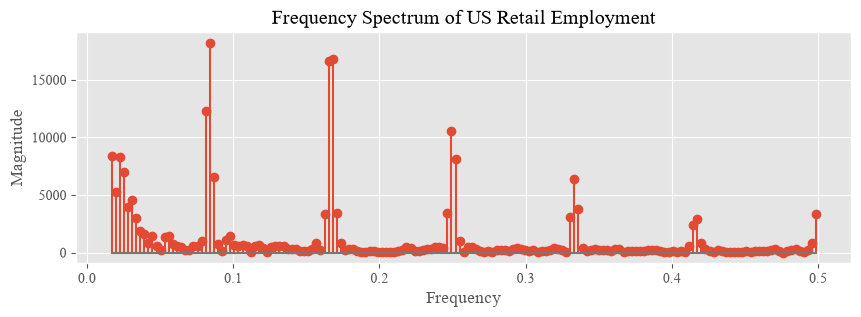

In [4]:
period, freqs, magnitudes = fft_analysis(us_retail_employment['y'],sampling_interval=1,min_cycles=6)

# Plotting the spectrum
plt.style.use('ggplot')
plt.figure(figsize=(10, 3))
plt.stem(freqs, magnitudes)
plt.title('Frequency Spectrum of US Retail Employment')
plt.xlabel('Frequency')
plt.ylabel('Magnitude')
plt.show()

## Fourier Transformation
<hr style="margin-top: -20px;">

**Fourier Series**

Any periodic function can be approximated by a combination of sine and cosine waves. The sine-cosine form of a Fourier series is as follows:

$$
S_{N(x)} = \frac{a_0}{2} + \sum_{n=1}^{N} (a_n \cdot cos(\frac{2\pi}{P} \cdot n \cdot x) + b_n \cdot sin(\frac{2\pi}{P} \cdot n \cdot x))
$$

where, $S_N$ is the N-term approximation of the signal, $S$. $P$ is the **maximum length** of the cycle. 

For time-series data we can use a few terms of the Fourier series to model our seasonality. Basically, we are trying to model the maximim length of the cycle, i.e. $P$.

**Example: Yearly Data** 

- $P$ = 12
- $x$ is an ordinal variable varying from 1 to P. So, $x$ becomes $1,2,3,...,12$.
- $a_n$ and $b_n$ can be determined if we perform regression on our time series. In other words, they are the **Regression Coefficients**.

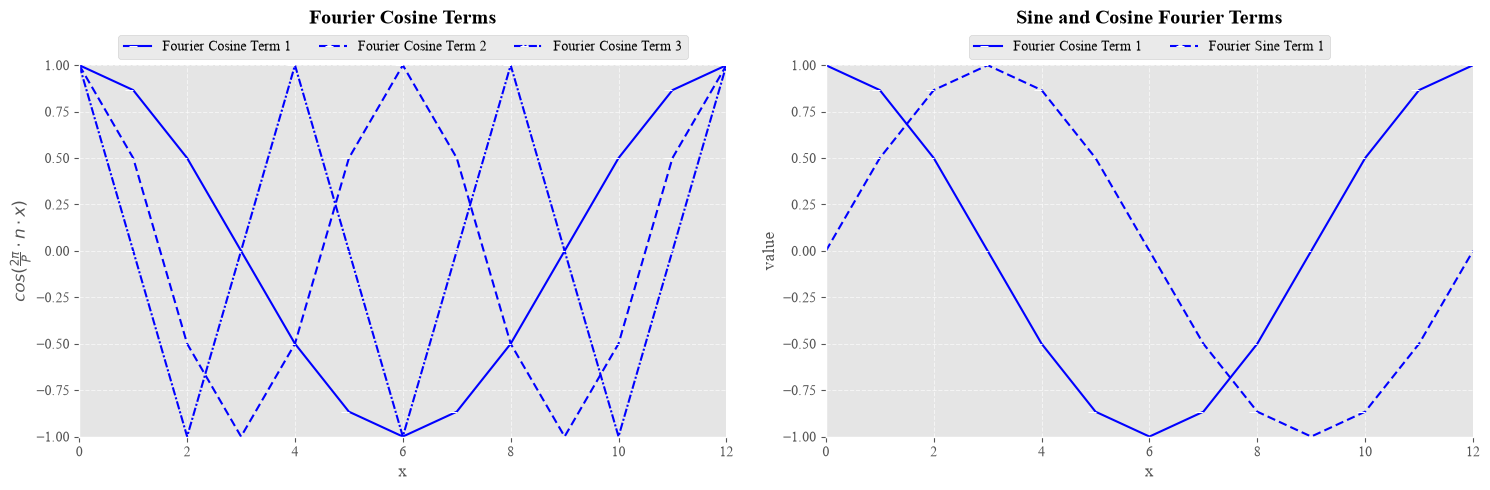

In [6]:
# Considering P=12

df = pd.DataFrame({"x": np.arange(13)})

for i in range(1,4):
    df[f'Fourier Cosine Term {i}'] = np.cos((2 * np.pi * df.x * i) / 12)
    df[f'Fourier Sine Term {i}'] = np.sin((2 * np.pi * df.x * i) / 12)

df = pd.melt(df, id_vars="x",var_name="Fourier Terms")

# plt.style.use('default')
fig, ax = plt.subplots(ncols=2,figsize=(15, 5))

dash_styles = {
    'Fourier Cosine Term 1': '',            # Solid
    'Fourier Cosine Term 2': (4, 2),        # Dashed
    'Fourier Cosine Term 3': (4, 1, 1, 1)   # Dash-dot
}

dash_styles_1 = {
    'Fourier Cosine Term 1': '',            # Solid
    'Fourier Sine Term 1': (4, 2),        # Dashed
}

sns.lineplot(data=df[df['Fourier Terms'].str.contains("Cosine")], x='x', y='value', style='Fourier Terms',color='blue',dashes=dash_styles,marker=False,ax=ax[0])
sns.lineplot(data=df[df['Fourier Terms'].str.contains("Term 1")], x='x', y='value', style='Fourier Terms',color='blue',dashes=dash_styles_1,marker=False,ax=ax[1])

ax[0].set_title('Fourier Cosine Terms', pad=30,fontweight='bold')
ax[0].set_ylabel(r"$cos(\frac{2\pi}{P} \cdot n \cdot x)$")

ax[1].set_title('Sine and Cosine Fourier Terms', pad=30,fontweight='bold')

for axis in ax:
    axis.grid(True, linestyle='--', alpha=0.6)
    axis.legend(loc='upper center',bbox_to_anchor=(0.5, 1.1), ncol=3)
    axis.margins(x=0,y=0)
    sns.despine()

plt.tight_layout()
plt.show()

In [7]:
ts = pd.read_parquet('./datasets/hourlyblock_file_7.parquet')
display(ts.head())

,timestamp,LCLid,energy_consumption,frequency,series_length,stdorToU,Acorn,Acorn_grouped,file,holidays,...,windBearing,temperature,dewPoint,pressure,apparentTemperature,windSpeed,precipType,icon,humidity,summary
0,2011-12-09 00:00:00+00:00,MAC000050,0.137,30 min,38976,Std,ACORN-D,Affluent,block_7,NO_HOLIDAY,...,267.0,7.27,1.55,1006.59,3.31,7.39,rain,clear-night,0.67,Clear
1,2011-12-09 00:30:00+00:00,MAC000050,0.113,30 min,38976,Std,ACORN-D,Affluent,block_7,NO_HOLIDAY,...,267.0,7.27,1.55,1006.59,3.31,7.39,NaN,NaN,0.67,NaN
2,2011-12-09 01:00:00+00:00,MAC000050,0.094,30 min,38976,Std,ACORN-D,Affluent,block_7,NO_HOLIDAY,...,261.0,6.43,1.67,1007.12,2.46,6.69,rain,clear-night,0.72,Clear
3,2011-12-09 01:30:00+00:00,MAC000050,0.066,30 min,38976,Std,ACORN-D,Affluent,block_7,NO_HOLIDAY,...,261.0,6.43,1.67,1007.12,2.46,6.69,NaN,NaN,0.72,NaN
4,2011-12-09 02:00:00+00:00,MAC000050,0.092,30 min,38976,Std,ACORN-D,Affluent,block_7,NO_HOLIDAY,...,257.0,6.29,0.45,1007.85,2.18,6.96,rain,clear-night,0.66,Clear


In [8]:
from src.imputation.interpolation import SeasonalInterpolation

# Taking a single time series from the block
ts_df = ts[ts.LCLid=="MAC000193"].set_index("timestamp")
ts_imp = SeasonalInterpolation(seasonal_period=48*7).fit_transform(ts_df.energy_consumption.values.reshape(-1,1)).squeeze()

**Using Fourier series for decomposition**

We can implement the **Fourier Decomposition** in Python useing LOESS for trend detection and Fourier terms for seasonality extraction. The key parameters that are involved in this process are as follows:

- `seasonality_period` is the seasonality to be extracted from the datetime index. pandas datetime properties, such as week_of_day and month, can be used to specify the most prominent seasonality. If left set to None, you need to provide the seasonality array while calling fit.
- `model` takes `additive` or `multiplicative` as an argument to determine the type of decomposition.
- `n_fourier_terms` determines the number of Fourier terms to be used to extract the seasonality. The more we increase this parameter, the more complex the seasonality that is extracted from the data.
- `lo_frac` is the fraction of the data that will be used to fit the LOESS regression.
- `lo_delta` is the fractional distance within which we use linear interpolation instead of weighted regression. Using a non-zero lo_delta significantly decreases computation time.

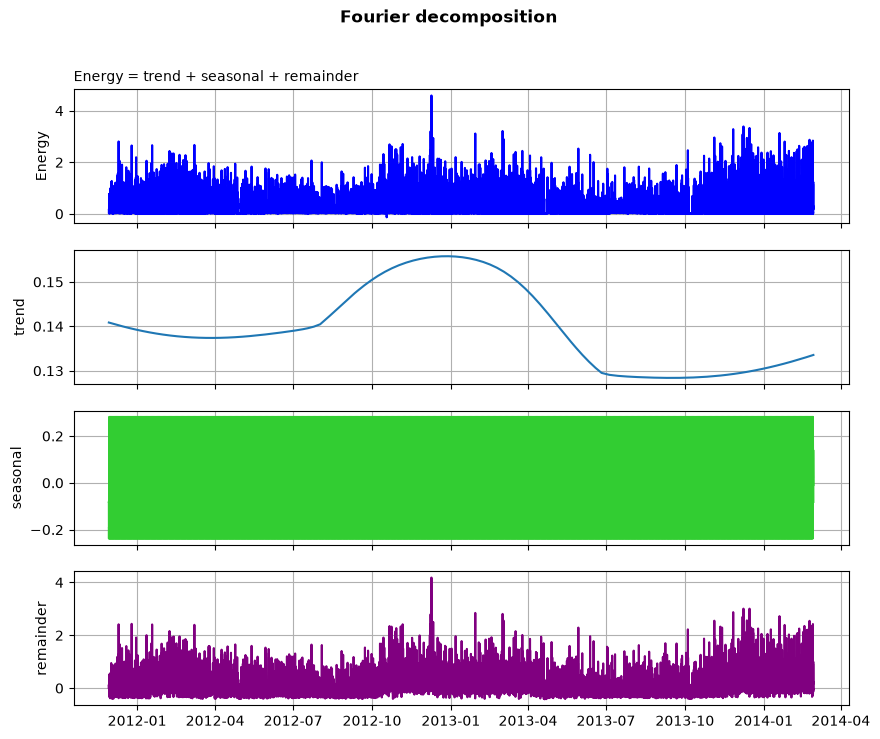

In [9]:
from src.decomposition.fourier import FourierDecomposition

#Doesn't support missing values, and expects a series or datafeame with datetime index
stl = FourierDecomposition(seasonality_period="hour", model = "additive", n_fourier_terms=5)
res_new = stl.fit(pd.Series(ts_imp.squeeze(), index=ts_df.index))

fou_dcmp = pd.DataFrame({
    "ds": ts_df.index,
    "data": res_new.observed,
    "trend": res_new.trend,
    "seasonal": res_new.seasonal,
    "remainder": res_new.resid,
}).reset_index(drop=True)

plt.style.use('default')
fig, axes = plt.subplots(4, 1, sharex=True, figsize=(10, 8))
sns.lineplot(data=fou_dcmp, x="ds", y="data", ax=axes[0],color='blue')
sns.lineplot(data=fou_dcmp, x="ds", y="trend", ax=axes[1])
sns.lineplot(data=fou_dcmp, x="ds", y="seasonal", ax=axes[2],color='limegreen')
sns.lineplot(data=fou_dcmp, x="ds", y="remainder", ax=axes[3],color='purple')
axes[0].set_title("Energy = trend + seasonal + remainder", size="medium", loc="left")
axes[0].set(ylabel="Energy")
axes[3].set(xlabel="")
for ax in axes:
    ax.grid(True)
fig.suptitle("Fourier decomposition",fontweight='bold')
plt.show()

We can’t see the seasonal pattern because it’s too small in the grand scale of the plot. Let’s also look at the decomposition for just **one month** to see the extracted seasonality patterns clearer

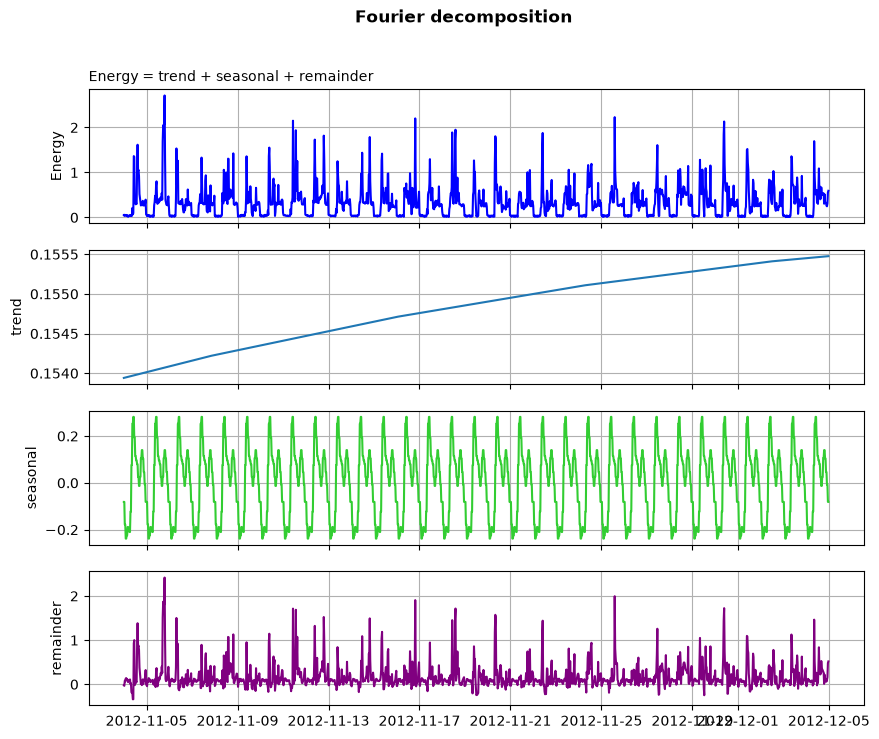

In [10]:
fou_dcmp.set_index('ds',inplace=True)

shortened_series = fou_dcmp["2012-11-4":"2012-12-4"]

fig, axes = plt.subplots(4, 1, sharex=True, figsize=(10, 8))
sns.lineplot(data=shortened_series, x=shortened_series.index, y="data", ax=axes[0],color='blue')
sns.lineplot(data=shortened_series, x=shortened_series.index, y="trend", ax=axes[1])
sns.lineplot(data=shortened_series, x=shortened_series.index, y="seasonal", ax=axes[2],color='limegreen')
sns.lineplot(data=shortened_series, x=shortened_series.index, y="remainder", ax=axes[3],color='purple')
axes[0].set_title("Energy = trend + seasonal + remainder", size="medium", loc="left")
axes[0].set(ylabel="Energy")
axes[3].set(xlabel="")
for ax in axes:
    ax.grid(True)
fig.suptitle("Fourier decomposition",fontweight='bold')
plt.show()

## Stationarity
<hr style="margin-top: -20px;">

**Why is stationarity important?**

- Stationarity is a fundamental assumption in many time series forecasting models. Without it many basic time series models would break.
- Transformations can be applied to convert a nonstationary time series to a stationary one.

**Stationary Time Series :** A stationary time series implies that specific statistical properties do not vary over time and remain steady, making the processes easier to model and predict.  

There are **Two** approaches to stationarity. A stochastic process $X(t) : t \in \mathcal{T}$ is called **strictly stationary** if the joint distribution of any set of observations in the series remains the same regardless of the time at which the observations are taken. Strict stationarity is very difficult to verify, especially from a limited amount of data. For this reason, one checks the **Weak stationarity**. A _weakly stationary time series_ is defined as a time series with:
- a constant `mean` ($\mu$), 
- a constant `variance` ($\sigma^2$), and 
- a consistent `covariance` (or autocorrelation) between identical distanced periods (lags).

**Non-Stationary Time Series :** A non-stationary process is more complex to model due to the dynamic nature and variations over time (for example, in the presence of trend or seasonality). A time series with **trend** or **seasonality** can be considered non-stationary. Usually, spotting trends or seasonality visually in a plot can help you determine whether the time series is stationary or not.

Text(0.5, 1.0, 'Non-stationary Time Series')

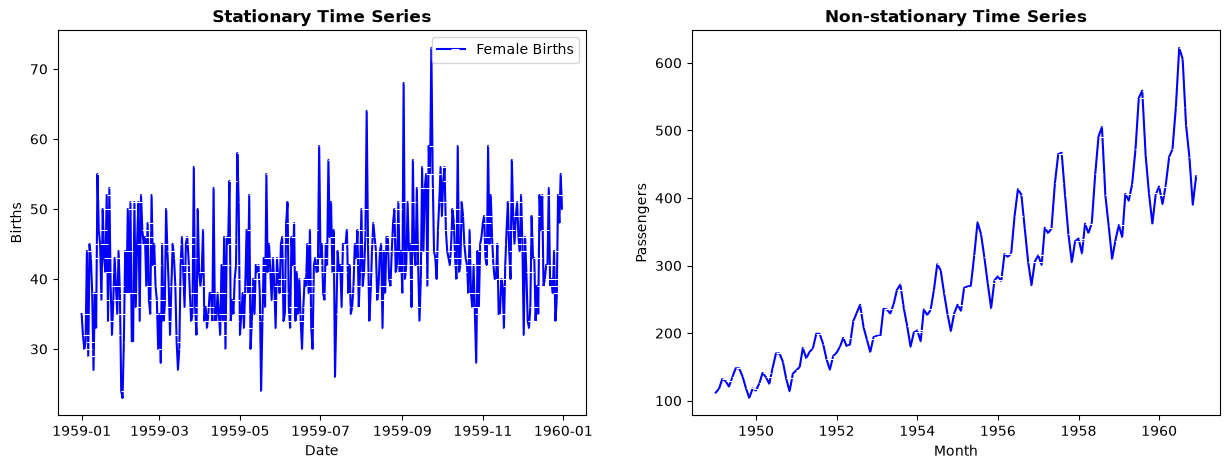

In [11]:
stationary_ts = pd.read_csv('./datasets/daily-total-female-births.csv',parse_dates=True)
non_stationary_ts = pd.read_csv('./datasets/airline-passengers.csv',parse_dates=True)

stationary_ts['Date'] = pd.to_datetime(stationary_ts['Date'])
non_stationary_ts['Month'] = pd.to_datetime(non_stationary_ts['Month'])

stationary_ts.set_index('Date',inplace=True)
non_stationary_ts.set_index('Month',inplace=True)

fig, ax = plt.subplots(ncols=2,figsize=(15, 5))
sns.lineplot(data=stationary_ts, x=stationary_ts.index, y='Births', color='blue',marker=True,ax=ax[0],label="Female Births")
sns.lineplot(data=non_stationary_ts, x=non_stationary_ts.index, y='Passengers', color='blue',marker=True,ax=ax[1])

ax[0].set_title("Stationary Time Series",fontweight='bold')
ax[1].set_title("Non-stationary Time Series",fontweight='bold')


**Checks for Stationarity**

There are many methods to check whether a time series (direct observations, residuals, otherwise) is stationary or non-stationary.
1. **Look at Plots:** You can review a time series plot of your data and visually check if there are any obvious trends or seasonality.
2. **Summary Statistics:** You can review the summary statistics for your data for seasons or random partitions and check for obvious or significant differences.
3. **Statistical Tests:** You can use statistical tests to check if the expectations of stationarity are met or have been violated.

Above, we have already introduced the `Daily Female Births` and `Airline Passengers` datasets as stationary and non-stationary respectively with plots showing an obvious lack and presence of trend and seasonality components.

**Summary Statistics**

- An easy way to check for constant mean and variance is to chop up the data into separate chunks.
- Then, one calculates statistics for each chunk, and compare them.
- Large deviations in either the mean or the variance among chunks might indicate that the time series is nonstationary.
- It’s not a rigorous method but gives a good hint of whether the data is approximately stationary or not.

We can split the time series into approximately equal contiguous sequences. We can then calculate the mean and variance of each group of numbers and compare the values. First, we will look into the `Female births` dataset.

In [12]:
# split data into 5 chunks
chunks = np.split(stationary_ts, indices_or_sections=5)

print("{}\t | {}\t\t | {}".format("Chunk", "Mean", "Variance"))
print("-" * 35)
for i, chunk in enumerate(chunks, 1):
    print("{:2}\t | {:.5}\t | {:.5}".format(i, np.mean(chunk), np.var(chunk)))

Chunk	 | Mean		 | Variance
-----------------------------------
 1	 | 39.74	 | 56.028
 2	 | 39.562	 | 47.835
 3	 | 41.425	 | 42.299
 4	 | 46.151	 | 52.155
 5	 | 43.027	 | 41.26


Now, look at the `Air Passenger` dataset.

In [13]:
# split data into 4 chunks
chunks = np.split(non_stationary_ts, indices_or_sections=4)

print("{}\t | {}\t\t | {}".format("Chunk", "Mean", "Variance"))
print("-" * 35)
for i, chunk in enumerate(chunks, 1):
    print("{:2}\t | {:.5}\t | {:.5}".format(i, np.mean(chunk), np.var(chunk)))

Chunk	 | Mean		 | Variance
-----------------------------------
 1	 | 145.5	 | 604.92
 2	 | 220.31	 | 1085.3
 3	 | 326.89	 | 3455.2
 4	 | 428.5	 | 6118.3


Apply the statistical test on the **Energy Consumption Data**.

In [14]:
# split data into 4 chunks
chunks = np.split(ts_imp, indices_or_sections=4)

print("{}\t | {}\t\t | {}".format("Chunk", "Mean", "Variance"))
print("-" * 35)
for i, chunk in enumerate(chunks, 1):
    print("{:2}\t | {:.5}\t | {:.5}".format(i, np.mean(chunk), np.var(chunk)))

Chunk	 | Mean		 | Variance
-----------------------------------
 1	 | 0.24989	 | 0.10957
 2	 | 0.24534	 | 0.10785
 3	 | 0.21554	 | 0.088508
 4	 | 0.26151	 | 0.1426


**Statistical Test**

Statistical tests make strong assumptions about your data. They can provide a quick check and confirmatory evidence that your time series is stationary or non-stationary.
The `Augmented Dickey-Fuller` test is a type of statistical test called a unit root test. There are a number of unit root tests and the Augmented Dickey-Fuller may be one of the more widely used. It uses an <u>autoregressive model</u> and optimizes an <u>information criterion</u> across multiple different lag values. The hypothesis that is associated with this test is:
1. **Null Hypothesis**: $H_0$: The series is non-stationary.
2. **Alternate Hypothesis**: $H_A$: The series is stationary.

We interpret this result using the p-value from the test.

- $p-value > 0.05$: Fail to reject the null hypothesis ($H_0$), the data has a unit root and is non-stationary.
- $p-value ≤ 0.05$:  Reject the null hypothesis ($H_0$), the data does not have a unit root and is stationary.

<div class="alert alert-block alert-info">
  <b>Note:</b> <br>
  The ADF test might be inaccurate with small datasets or when heteroskedasticity is present.<br>
  It is best to pair ADF with other techniques (run-sequence plots, summary statistics, histograms, etc..).
</div>

Below is an example of calculating the **Augmented Dickey-Fuller** test on the Daily Female Births dataset. The `Statsmodels` library provides the `adfuller()` function that implements the test.

In [15]:
from statsmodels.tsa.stattools import adfuller

X=stationary_ts['Births'].values
result=adfuller(X)

print('ADF Statistic:%f' %result[0])
print('p-value:%f' %result[1])
print('CriticalValues:')
for key,value in result[4].items():
    print('\t%s: %.3f' %(key,value))

ADF Statistic:-4.808291
p-value:0.000052
CriticalValues:
	1%: -3.449
	5%: -2.870
	10%: -2.571


This suggests that we can reject the null hypothesis with a significance level of less than 1% (i.e. a low probability that the result is a statistical fluke).Rejecting the null hypothesis means that the process has **no** unit root,and in turn that the **time series is stationary** or does not have time-dependent structure.

Next, we will explore **Kwiatkowski-Phillips-Schmidt-Shin (KPSS)** test also implemented using the **Statsmodels**. This is similar to **Adfuller** test, the only difference being that the KPSS has the **opposite null hypothesis**, which assumes the time series is stationary. Therefore, you will need to interpret the test results to determine whether you can reject or fail to reject the null hypothesis.
1. **Null Hypothesis**: $H_0$: The series is stationary.
2. **Alternate Hypothesis**: $H_A$: The series is non-stationary.

For this exercise, we are going to use weekly carbon dioxide levels measured in **parts per million (ppm)** from 1960 to 2000.

In [16]:
from src.stationarity.stats import kpss_results,adf_results
import warnings
warnings.filterwarnings('ignore')

co2_df = pd.read_csv('./datasets/co2.csv')

adf_output = adf_results(co2_df['co2'])
kpss_output = kpss_results(co2_df['co2'])

print(pd.concat([adf_output,kpss_output],axis=1))

                                  ADF            KPSS
Test Statistic               0.046051        7.649196
p-value                      0.962179            0.01
Number of lags                     27              29
Decision               Non-Stationary  Non-Stationary
Critical Value (1%)         -3.433252           0.739
Critical Value (5%)         -2.862822           0.463
Critical Value (10%)        -2.567452           0.347
Critical Value (2.5%)             NaN           0.574


<Axes: >

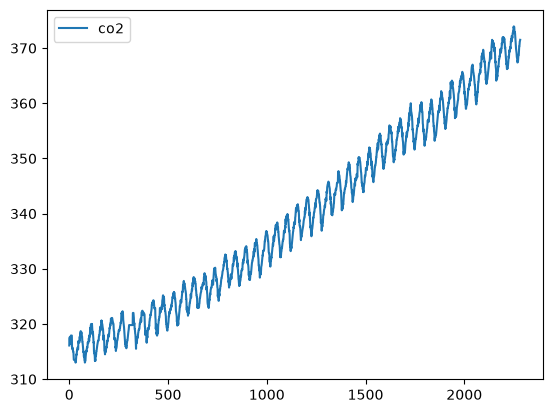

In [17]:
co2_df.plot()

## **Common transformations to achieve stationarity**
<hr style="margin-top: -20px;">

We will explore **eight** techniques for making the time series stationary, such as transformations and differencing. The techniques covered are first-order differencing, 
second-order differencing, subtracting moving average, log transformation, decomposition, and Hodrick-Prescott filter.

Let's implement some of the methods for making the time series stationary or extracting a stationary component. 

1. **First-order differencing:**  Also known as detrending, which is calculated by subtracting an observation at time `t` from the previous observation at time `t-1` ($y_t - y_{t-1}$). In pandas this can be done using the `.diff()` function, which defaults to period=1. Note that the differenced data will contain one less data point (row) than the original data, hence the use of the `.dropna()` method:

In [18]:
co2_df['date'] = pd.to_datetime(co2_df['date'])
co2_df = co2_df.set_index('date')

first_ord_diff = co2_df.diff().dropna()

2. **Second-order differencing:** This is useful if seasonality exists or if the first-order differencing was insufficient. This is essentially **differencing twice** – differencing to remove seasonality followed by differencing to remove trend:

In [19]:
second_ord_diff = co2_df.diff().diff().dropna()

3. **Year-over-Year (YoY) Seasonality** computes the year-over-year change (since 52 weeks $\approx$ 1 year), effectively removing annual seasonal effects.

In [20]:
deseasonalize = co2_df.diff(52).dropna()

4. **Subtracting moving average** (rolling window) from the time series using DataFrame.rolling(window=52).mean() since it is weekly data:

In [23]:
rolling_mean = co2_df.rolling(window=52).mean()
rolling_mean = co2_df - rolling_mean

5. **Log transformation** using np.log() is a common technique to stabilize the variance in a time series and sometimes enough to make the time series stationary. Simply, all it does is replace each observation with its log value:

In [24]:
log_transform = np.log(co2_df)

6. Using time series **classical decomposition** to remove the trend component, such as `seasonal_decompose`. We are using an `additive` model which is the default parameter in seasonal_decompose.

In [25]:
decomp = seasonal_decompose(co2_df)
seasonal_decomp = decomp.resid

7. Using time series **STL decomposition** to remove the trend component, such as `STL`.

In [26]:
co2_stl = STL(co2_df, seasonal=13,robust=True).fit()
stl_decomp = co2_stl.resid

8. The **Hodrick-Prescott filter** is a smoothing filter that can be used to separate short-term fluctuations (cyclic variations) from long-term trends. This is implemented as `hp_filter` in the `statsmodels` library. Unlike the existing decomposition techniques, `hp_filter` returns two components, a cyclical component and a trend component. We will be using the **Hodrick-Prescott filter** to remove the trend component, by using `hp_filter`:

In [27]:
hp_cyclic, hp_trend = hpfilter(co2_df)

In [28]:
# These are methods we are using for the transforming the time-series
methods = [first_ord_diff, second_ord_diff, deseasonalize, rolling_mean, log_transform,  seasonal_decomp, stl_decomp, hp_cyclic]

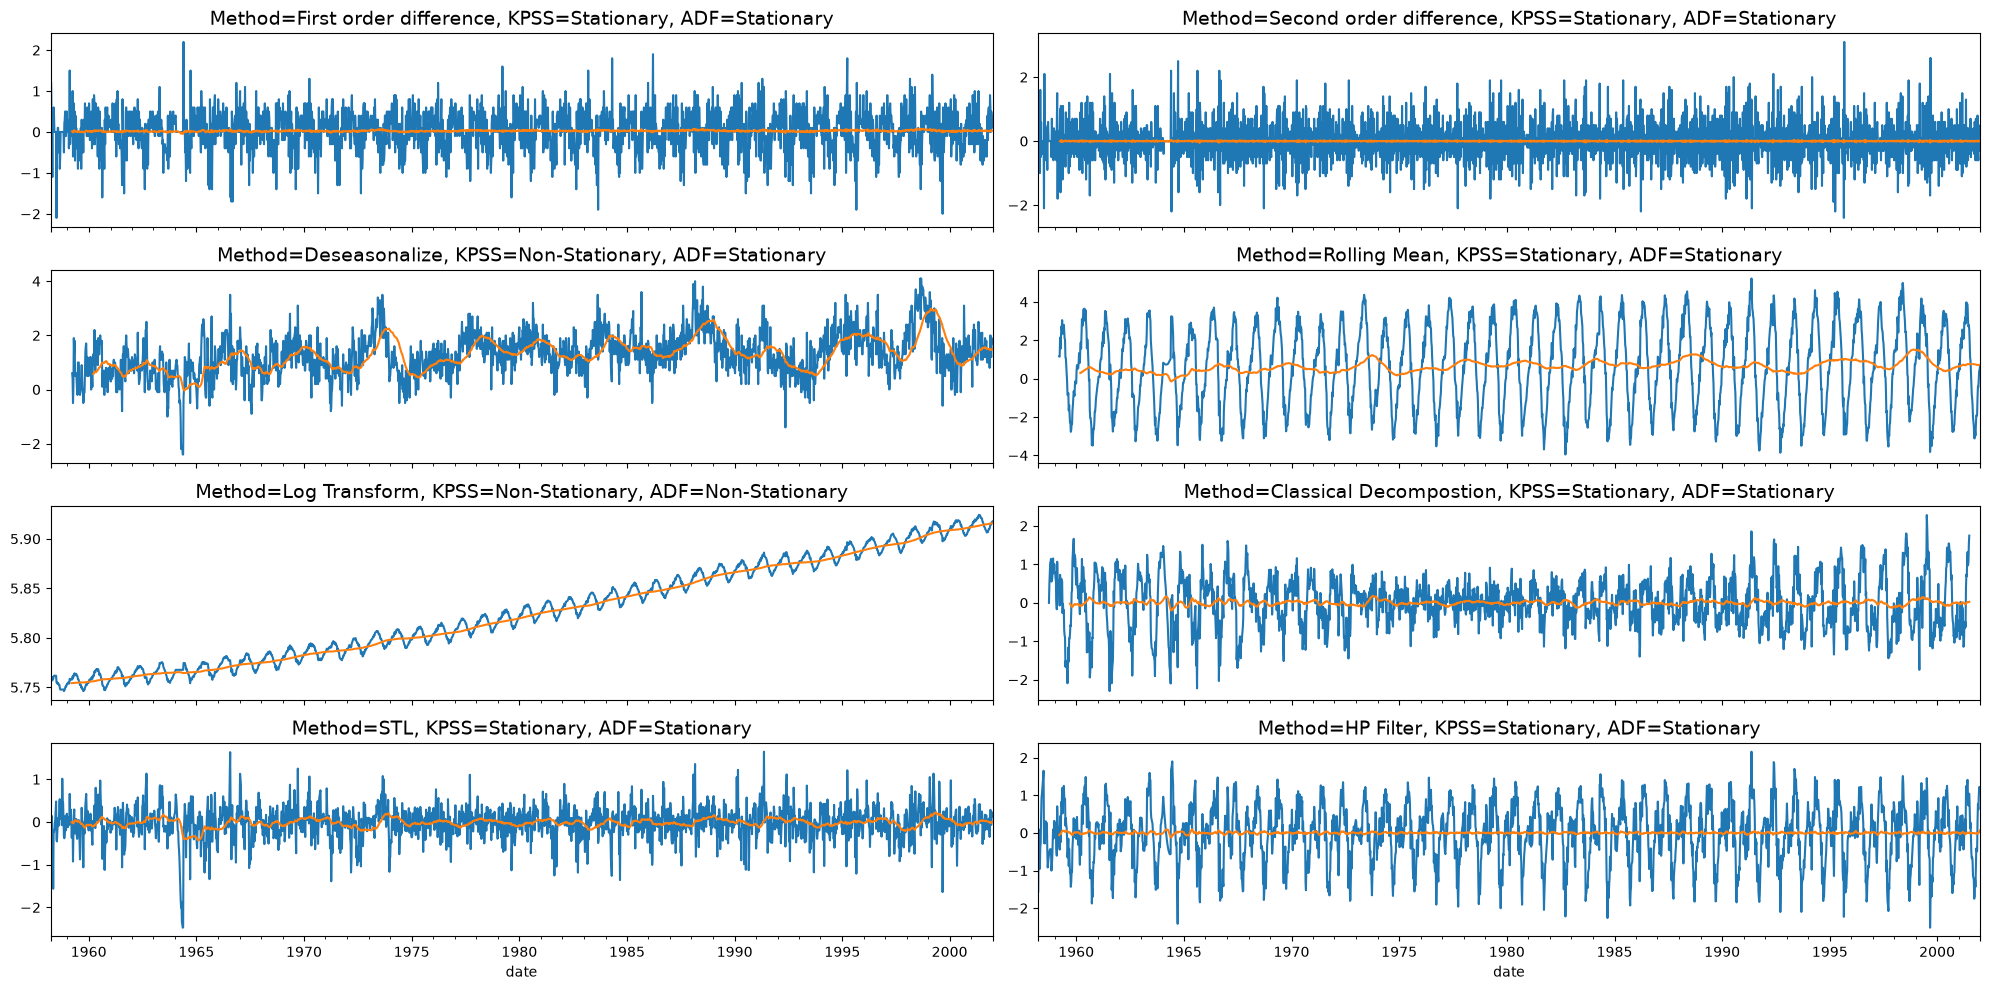

In [ ]:
%reload_ext autoreload
%autoreload 2

import importlib
import src.stationarity.stats
importlib.reload(src.stationarity.stats)

from src.stationarity.stats import plot_comparison

plot = plot_comparison(methods, kpss_results, adf_results, plot_type='line')
warnings.simplefilter(action='ignore')

Generally, you do not want to over-difference your time series as some studies have shown that models based on over-differenced data are less accurate. For example, first_
order_diff already made the time series stationary, and thus there was no need to difference it any further. In other words, differencing twice was not needed. Additionally, notice how `log_transform` is still non-stationary. 

In [ ]:
households = ts.LCLid.unique()

hh_modified_ts = []

for hh in households:
    ts_mod = ts[ts.LCLid==hh]
    ts_mod_imp = SeasonalInterpolation(seasonal_period=48*7).fit_transform(ts_mod.energy_consumption.values.reshape(-1,1)).squeeze()
    ts_mod['energy_consumption'] = ts_mod_imp
    hh_modified_ts.append(ts_mod)

time_series_mod = pd.concat(hh_modified_ts)

,timestamp,LCLid,energy_consumption,frequency,series_length,stdorToU,Acorn,Acorn_grouped,file,holidays,...,windBearing,temperature,dewPoint,pressure,apparentTemperature,windSpeed,precipType,icon,humidity,summary
0,2011-12-09 00:00:00+00:00,MAC000050,0.137000,30 min,38976,Std,ACORN-D,Affluent,block_7,NO_HOLIDAY,...,267.0,7.27,1.55,1006.59,3.31,7.39,rain,clear-night,0.67,Clear
1,2011-12-09 00:30:00+00:00,MAC000050,0.113000,30 min,38976,Std,ACORN-D,Affluent,block_7,NO_HOLIDAY,...,267.0,7.27,1.55,1006.59,3.31,7.39,NaN,NaN,0.67,NaN
2,2011-12-09 01:00:00+00:00,MAC000050,0.094000,30 min,38976,Std,ACORN-D,Affluent,block_7,NO_HOLIDAY,...,261.0,6.43,1.67,1007.12,2.46,6.69,rain,clear-night,0.72,Clear
3,2011-12-09 01:30:00+00:00,MAC000050,0.066000,30 min,38976,Std,ACORN-D,Affluent,block_7,NO_HOLIDAY,...,261.0,6.43,1.67,1007.12,2.46,6.69,NaN,NaN,0.72,NaN
4,2011-12-09 02:00:00+00:00,MAC000050,0.092000,30 min,38976,Std,ACORN-D,Affluent,block_7,NO_HOLIDAY,...,257.0,6.29,0.45,1007.85,2.18,6.96,rain,clear-night,0.66,Clear
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1619131,2014-02-27 21:30:00+00:00,MAC005370,0.121501,30 min,35280,Std,ACORN-D,Affluent,block_7,NO_HOLIDAY,...,217.0,5.03,1.67,1006.36,2.50,3.06,NaN,NaN,0.79,NaN
1619132,2014-02-27 22:00:00+00:00,MAC005370,0.115666,30 min,35280,Std,ACORN-D,Affluent,block_7,NO_HOLIDAY,...,216.0,4.10,1.64,1005.67,1.41,3.02,rain,clear-night,0.84,Clear
1619133,2014-02-27 22:30:00+00:00,MAC005370,0.114544,30 min,35280,Std,ACORN-D,Affluent,block_7,NO_HOLIDAY,...,216.0,4.10,1.64,1005.67,1.41,3.02,NaN,NaN,0.84,NaN
1619134,2014-02-27 23:00:00+00:00,MAC005370,0.113966,30 min,35280,Std,ACORN-D,Affluent,block_7,NO_HOLIDAY,...,200.0,3.93,1.61,1004.62,1.42,2.75,rain,clear-night,0.85,Clear


In [33]:
ts

,timestamp,LCLid,energy_consumption,frequency,series_length,stdorToU,Acorn,Acorn_grouped,file,holidays,...,windBearing,temperature,dewPoint,pressure,apparentTemperature,windSpeed,precipType,icon,humidity,summary
0,2011-12-09 00:00:00+00:00,MAC000050,0.137,30 min,38976,Std,ACORN-D,Affluent,block_7,NO_HOLIDAY,...,267.0,7.27,1.55,1006.59,3.31,7.39,rain,clear-night,0.67,Clear
1,2011-12-09 00:30:00+00:00,MAC000050,0.113,30 min,38976,Std,ACORN-D,Affluent,block_7,NO_HOLIDAY,...,267.0,7.27,1.55,1006.59,3.31,7.39,NaN,NaN,0.67,NaN
2,2011-12-09 01:00:00+00:00,MAC000050,0.094,30 min,38976,Std,ACORN-D,Affluent,block_7,NO_HOLIDAY,...,261.0,6.43,1.67,1007.12,2.46,6.69,rain,clear-night,0.72,Clear
3,2011-12-09 01:30:00+00:00,MAC000050,0.066,30 min,38976,Std,ACORN-D,Affluent,block_7,NO_HOLIDAY,...,261.0,6.43,1.67,1007.12,2.46,6.69,NaN,NaN,0.72,NaN
4,2011-12-09 02:00:00+00:00,MAC000050,0.092,30 min,38976,Std,ACORN-D,Affluent,block_7,NO_HOLIDAY,...,257.0,6.29,0.45,1007.85,2.18,6.96,rain,clear-night,0.66,Clear
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1619131,2014-02-27 21:30:00+00:00,MAC005370,NaN,30 min,35280,Std,ACORN-D,Affluent,block_7,NO_HOLIDAY,...,217.0,5.03,1.67,1006.36,2.50,3.06,NaN,NaN,0.79,NaN
1619132,2014-02-27 22:00:00+00:00,MAC005370,NaN,30 min,35280,Std,ACORN-D,Affluent,block_7,NO_HOLIDAY,...,216.0,4.10,1.64,1005.67,1.41,3.02,rain,clear-night,0.84,Clear
1619133,2014-02-27 22:30:00+00:00,MAC005370,NaN,30 min,35280,Std,ACORN-D,Affluent,block_7,NO_HOLIDAY,...,216.0,4.10,1.64,1005.67,1.41,3.02,NaN,NaN,0.84,NaN
1619134,2014-02-27 23:00:00+00:00,MAC005370,NaN,30 min,35280,Std,ACORN-D,Affluent,block_7,NO_HOLIDAY,...,200.0,3.93,1.61,1004.62,1.42,2.75,rain,clear-night,0.85,Clear
